# [HW1] Ground and wall detection

Frolova AI, M25-RO-01

`https://github.com/kicchhi/Advanced-Robotics`

## Home assignment 1.1
## Wall Detection (2D LIDAR + Hough Transform)
Задача: Найти прямые линии (стены) в облаке точек 2D-лидара.
Данные:
- Intel Research Lab Dataset: Классический датасет 2D-сканов.
- Синтетика (рекомендуется): Сгенерировать в Python массив точек, образующих прямоугольник (контуры комнаты) с
шумом. Это позволит приступить к алгоритму, не тратя время на парсинг сложных форматов файлов.
Пайплайн:
1. Написать функцию перевода координат.
2. Создать аккумулятор Хафа.
3. Найти пики в аккумуляторе.
4. Результат: отрисовать найденные линии стен поверх точек лидара.

In [ ]:
!pip install open3d

# Импорт необходимых библиотек

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import open3d as o3d
import copy
import random
from skimage.transform import hough_line, hough_line_peaks
from skimage.draw import line as draw_line

# Основные функции

In [3]:
# За основу взят код из лабораторной работы
def make_walls(vertex, body, step=0.4, scale=0.1):
    """
    Генерирует точки вдоль стен комнаты с шумом.

    Параметры:
        vertex (np.array): массив вершин комнаты
        body (np.array): координаты робота (не используется, но оставлено для совместимости)
        step (float): шаг между точками
        scale (float): масштаб шума

    Возвращает:
        np.array: массив точек стен
    """
    x_, y_ = [], []
    # Проходим по всем стенам (кроме последней)
    for i in range(vertex.shape[0]-1):
        x0, y0 = vertex[i]
        x1, y1 = vertex[i+1]
        r = np.linalg.norm(vertex[i] - vertex[i+1])
        n = np.round(r/step).astype(int)
        x_.append(np.linspace(x0, x1, n) + np.random.normal(loc=0, scale=scale, size=(n)))
        y_.append(np.linspace(y0, y1, n) + np.random.normal(loc=0, scale=scale, size=(n)))

    # Замыкаем контур (последняя стена от последней вершины к первой)
    x0, y0 = vertex[-1]
    x1, y1 = vertex[0]
    r = np.linalg.norm(vertex[-1] - vertex[0])
    n = np.round(r/step).astype(int)
    x_.append(np.linspace(x0, x1, n) + np.random.normal(loc=0, scale=scale, size=(n)))
    y_.append(np.linspace(y0, y1, n) + np.random.normal(loc=0, scale=scale, size=(n)))

    # Объединяем все сегменты
    x = np.concat(x_, axis=0)
    y = np.concat(y_, axis=0)
    walls = np.stack((x, y), axis=1)
    return walls

# конфигурация комнаты
vertex = np.array([
    [0, 0],
    [0, 12],
    [5, 12],
    [5, 8],
    [10, 8],
    [10, 12],
    [15, 12],
    [15, 0],
    [10, 0],
    [10, 4],
    [5, 4],
    [5, 0]
])

body = np.array([5, 7])

walls = make_walls(vertex, body)

# Функция distance_point_to_line тоже из лабы
def distance_point_to_line(point, line_start, line_end):
    """
    Вычисляет перпендикулярное расстояние от точки до отрезка.

    Параметры:
        point: точка [x, y]
        line_start: начало отрезка [x, y]
        line_end: конец отрезка [x, y]

    Возвращает:
        float: расстояние
    """
    p = np.array(point)
    s = np.array(line_start)
    e = np.array(line_end)

    if np.array_equal(s, e):
        return np.linalg.norm(p - s)

    line_vec = e - s
    point_vec = p - s
    line_len = np.linalg.norm(line_vec)
    line_unit_vec = line_vec / line_len
    proj_length = np.dot(point_vec, line_unit_vec)

    if proj_length < 0:
        closest_point = s
    elif proj_length > line_len:
        closest_point = e
    else:
        closest_point = s + proj_length * line_unit_vec

    return np.linalg.norm(p - closest_point)

# Реализация алгоритма Рамера-Дугласа-Пекера
def split_and_merge(points, epsilon=0.5):
    """
    Алгоритм Split and Merge (Ramer-Douglas-Peucker) для упрощения облака точек.

    Параметры:
        points (np.array): массив точек
        epsilon (float): порог упрощения

    Возвращает:
        list: индексы ключевых точек
    """
    if len(points) < 2:
        return list(range(len(points)))

    line_start = points[0]
    line_end = points[-1]
    max_dist = 0
    index = 0

    for i in range(1, len(points) - 1):
        dist = distance_point_to_line(points[i], line_start, line_end)
        if dist > max_dist:
            index = i
            max_dist = dist

    if max_dist < epsilon:
        return [0, len(points) - 1]
    else:
        left_indices = split_and_merge(points[:index+1], epsilon)
        right_indices = split_and_merge(points[index:], epsilon)
        combined_indices = left_indices[:-1] + [x + index for x in right_indices]
        return combined_indices

# Применяем алгоритм Split and Merge
sparse_indices = split_and_merge(walls, epsilon=0.5)
sparse_walls = walls[sparse_indices]



Было точек: 700, стало ключевых точек: 14


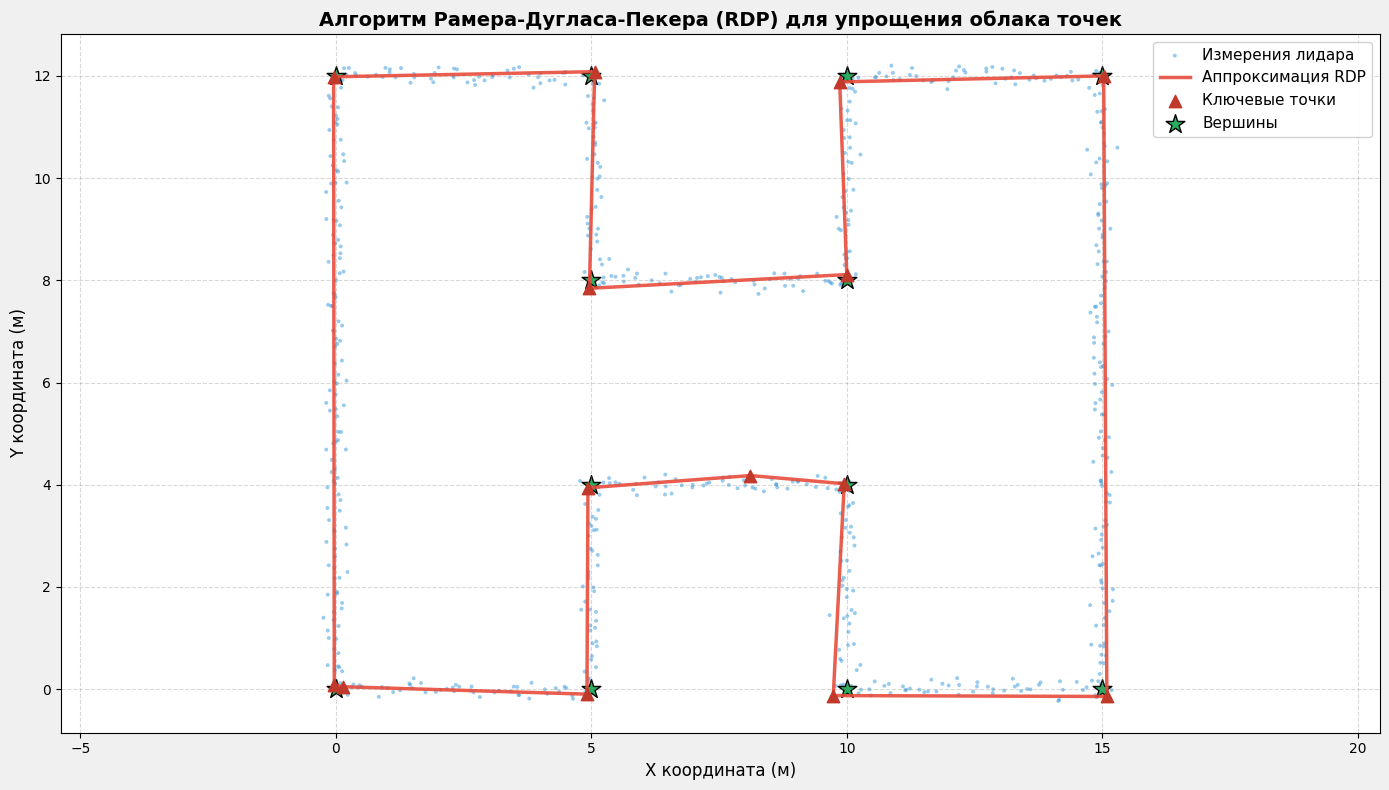

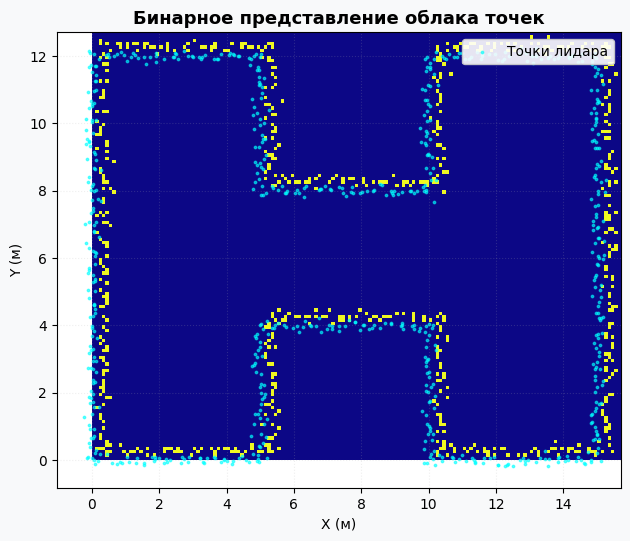

In [6]:
print(f"Было точек: {len(walls)}, стало ключевых точек: {len(sparse_walls)}")

plt.figure(figsize=(14, 8), facecolor='#f0f0f0')
plt.scatter(walls[:, 0], walls[:, 1], s=8, c='#3498db', alpha=0.5, label='Измерения лидара', edgecolors='none')
for i in range(len(sparse_walls) - 1):
    plt.plot(sparse_walls[i:i+2, 0], sparse_walls[i:i+2, 1], color='#e74c3c', linewidth=2.5, alpha=0.9)
plt.plot([sparse_walls[-1, 0], sparse_walls[0, 0]], [sparse_walls[-1, 1], sparse_walls[0, 1]],
         color='#e74c3c', linewidth=2.5, alpha=0.9, label='Аппроксимация RDP')
plt.scatter(sparse_walls[:, 0], sparse_walls[:, 1], c='#c0392b', marker='^', s=80, zorder=5, label='Ключевые точки')
plt.scatter(vertex[:, 0], vertex[:, 1], c='#27ae60', marker='*', s=200, label='Вершины', edgecolors='black', linewidth=1)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3, color='gray')
plt.axis('equal')
plt.xlabel('X координата (м)', fontsize=12)
plt.ylabel('Y координата (м)', fontsize=12)
plt.title('Алгоритм Рамера-Дугласа-Пекера (RDP) для упрощения облака точек', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

def points_to_image(points, pixel_size=0.1):
    """
    Конвертирует облако точек в бинарное изображение для преобразования Хафа.

    Параметры:
        points (np.array): массив точек
        pixel_size (float): размер пикселя в метрах

    Возвращает:
        np.array: бинарное изображение
    """
    min_coords = points.min(axis=0)
    max_coords = points.max(axis=0)
    x_range = max_coords[0] - min_coords[0]
    y_range = max_coords[1] - min_coords[1]
    buffer_units = pixel_size * 2
    img_width_units = x_range + buffer_units
    img_height_units = y_range + buffer_units
    img_width_pixels = int(np.ceil(img_width_units / pixel_size))
    img_height_pixels = int(np.ceil(img_height_units / pixel_size))
    image = np.zeros((img_height_pixels, img_width_pixels), dtype=np.uint8)
    offset_x = min_coords[0] - pixel_size
    offset_y = min_coords[1] - pixel_size
    pixel_x = ((points[:, 0] - offset_x) / pixel_size).astype(int)
    pixel_y = ((points[:, 1] - offset_y) / pixel_size).astype(int)
    pixel_x = np.clip(pixel_x, 0, img_width_pixels - 1)
    pixel_y = np.clip(pixel_y, 0, img_height_pixels - 1)
    image[pixel_y, pixel_x] = 255
    return image

# Генерируем точки для преобразования Хафа
step = 0.1
walls = make_walls(vertex, body, step=step)
pixel_size = 0.1
image_walls = points_to_image(walls, pixel_size=pixel_size)

tested_angles = np.linspace(-np.pi / 2, np.pi / 2, 360, endpoint=False)
h, theta, d = hough_line(image_walls, theta=tested_angles)

# Поиск пиков в пространстве Хафа
hspace, angles, dists = hough_line_peaks(h, theta, d, threshold=len(walls)*0.1)

fig = plt.figure(figsize=(16, 7), facecolor='#f8f9fa')

# График 1: Бинарное изображение с точками
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(image_walls, cmap='plasma', origin='lower',
           extent=[0, image_walls.shape[1]*pixel_size, 0, image_walls.shape[0]*pixel_size])
ax1.scatter(walls[:, 0], walls[:, 1], s=3, c='cyan', alpha=0.6, label='Точки лидара')
ax1.set_title('Бинарное представление облака точек', fontsize=13, fontweight='bold')
ax1.set_xlabel('X (м)')
ax1.set_ylabel('Y (м)')
ax1.grid(True, alpha=0.2, linestyle=':')
ax1.legend(loc='upper right', framealpha=0.9)


# Home assignment 1.2: Ground Detection (RANSAC)

Задача: Выделить плоскость пола из 3D облака точек, чтобы робот знал, где можно ехать.

Данные:
- Kitti Dataset: (Velodyne сканы) — файлы тяжелые, нужно прорядить облако точек.
- Датасеты RGB-D камер (TUM, NYU): Облака точек для обычных комнат.
- Альтернатива: Взять любой .pcd или .ply файл из примеров библиотеки Open3D.

Пайплайн:
1. Загрузка 3D облака точек (Point Cloud).
2. Реализация алгоритма RANSAC:
    - Выбрать 3 случайные точки.
    - Построить уравнение плоскости: ax + by + cz + d = 0
    - Посчитать расстояние от всех точек до этой плоскости.
    - Определить количество «инлайеров» (точек, лежащих на плоскости с заданным порогом).
    - Повторить N раз, чтобы выбрать лучшую плоскость.
3. Результат: Окрасить точки пола в один цвет, а все остальное (препятствия) — в другой.

# Импорт библиотек

In [ ]:
import open3d as o3d
import numpy as np
import random
import plotly.graph_objects as go
from sklearn.linear_model import RANSACRegressor

# Загрузка данных

In [ ]:
print("\nЗагрузка данных из Open3D...")
point_cloud = o3d.data.PCDPointCloud()
pcd = o3d.io.read_point_cloud(point_cloud.path)
pcd = pcd.uniform_down_sample(10)  # прореживаем для скорости
points = np.asarray(pcd.points)
print(f"   Загружено {len(points)} точек.")
print(f"   Диапазон X: [{points[:, 0].min():.2f}, {points[:, 0].max():.2f}]")
print(f"   Диапазон Y: [{points[:, 1].min():.2f}, {points[:, 1].max():.2f}]")
print(f"   Диапазон Z: [{points[:, 2].min():.2f}, {points[:, 2].max():.2f}]")

# Основные функции

In [5]:
# За основу взят код из лабы
def ransac_plane(points, distance_threshold=0.05, max_trials=1000, min_inlier_ratio=0.1):
    """
    Алгоритм RANSAC для поиска плоскости в облаке точек.

    Параметры:
        points (np.array): облако точек Nx3
        distance_threshold (float): порог расстояния для инлайнеров
        max_trials (int): максимальное число итераций
        min_inlier_ratio (float): минимальное соотношение инлайнеров для early stopping

    Возвращает:
        tuple: (параметры плоскости, индексы инлайнеров)
    """
    best_inliers = []
    best_plane = None
    num_points = len(points)
    min_good_inliers = int(num_points * min_inlier_ratio)

    print(f"\n   Запуск RANSAC: threshold={distance_threshold}, max_trials={max_trials}")

    for iteration in range(max_trials):
        # Выбрали 3 случайные точки
        idx = random.sample(range(num_points), 3)
        p1, p2, p3 = points[idx]

        # Уравнение плоскости ax + by + cz + d = 0
        v1 = p2 - p1
        v2 = p3 - p1
        normal = np.cross(v1, v2)
        norm_len = np.linalg.norm(normal)

        # Проверка на вырожденный случай (точки коллинеарны)
        if norm_len < 1e-6:
            continue

        normal = normal / norm_len
        d = -np.dot(normal, p1)

        # Расстояние от всех точек до плоскости
        distances = np.abs(np.dot(points, normal) + d)

        # Количество инлайнеров
        inliers = np.where(distances < distance_threshold)[0]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_plane = (normal[0], normal[1], normal[2], d)

        # Ранний выход, если нашли достаточно инлайнеров
        if len(inliers) > min_good_inliers:
            print(f"   Ранний выход на итерации {iteration+1}: {len(inliers)} инлайнеров")
            break

    return best_plane, best_inliers

# Запускаем RANSAC с хорошими параметрами
print("\nПоиск плоскости пола...")
plane_params, inlier_indices = ransac_plane(points, distance_threshold=0.05, max_trials=2000)

if plane_params is not None:
    a, b, c, d = plane_params
    print(f"\nНайдена плоскость: {a:.3f}x + {b:.3f}y + {c:.3f}z + {d:.3f} = 0")
    print(f"Количество инлайнеров (точек на полу/столе): {len(inlier_indices)} из {len(points)}")
    print(f"   ({100*len(inlier_indices)/len(points):.1f}% точек)")

    # Разделяем точки
    inlier_points = points[inlier_indices]
    outlier_mask = np.ones(len(points), dtype=bool)
    outlier_mask[inlier_indices] = False
    outlier_points = points[outlier_mask]

    print(f"Точек на полу: {len(inlier_points)}")
    print(f"Точек препятствий: {len(outlier_points)}")

    fig = go.Figure()

    # Инлайнеры зеленые
    fig.add_trace(go.Scatter3d(
        x=inlier_points[:, 0], y=inlier_points[:, 1], z=inlier_points[:, 2],
        mode='markers',
        marker=dict(size=2, color='green', opacity=0.8),
        name=f'Пол (инлайнеры) - {len(inlier_points)} точек'
    ))

    # Аутлайнеры красные
    fig.add_trace(go.Scatter3d(
        x=outlier_points[:, 0], y=outlier_points[:, 1], z=outlier_points[:, 2],
        mode='markers',
        marker=dict(size=2, color='red', opacity=0.6),
        name=f'Препятствия (аутлайнеры) - {len(outlier_points)} точек'
    ))

    xx, yy = np.meshgrid(
        np.linspace(points[:, 0].min(), points[:, 0].max(), 5),
        np.linspace(points[:, 1].min(), points[:, 1].max(), 5)
    )
    zz = (-a * xx - b * yy - d) / c

    fig.add_trace(go.Surface(
        x=xx, y=yy, z=zz,
        opacity=0.3,
        colorscale=[[0, 'yellow'], [1, 'yellow']],
        showscale=False,
        name='Найденная плоскость'
    ))

    fig.update_layout(
        title='RANSAC: Обнаружение плоскости пола',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data'
        ),
        width=1000,
        height=800,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01,
            bgcolor='rgba(255, 255, 255, 0.8)'
        )
    )

    fig.show()

else:
    print("Плоскость не найдена.")


Загрузка данных из Open3D...
[Open3D INFO] Downloading https://github.com/isl-org/open3d_downloads/releases/download/20220201-data/fragment.pcd
[Open3D INFO] Downloaded to /root/open3d_data/download/PCDPointCloud/fragment.pcd
   Загружено 11367 точек.
   Диапазон X: [1.15, 3.51]
   Диапазон Y: [0.82, 2.76]
   Диапазон Z: [0.73, 1.53]

Поиск плоскости пола...

   Запуск RANSAC: threshold=0.05, max_trials=2000
   Ранний выход на итерации 1: 9074 инлайнеров

Найдена плоскость: -0.064x + -0.102y + 0.993z + -1.033 = 0
Количество инлайнеров (точек на полу/столе): 9074 из 11367
   (79.8% точек)
Точек на полу: 9074
Точек препятствий: 2293
